<a href="https://colab.research.google.com/github/Darshan5564/DNN_Loan_Prediction/blob/main/DNN_Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# import necessary lib
import pandas as pd
import numpy as np
data = pd.read_csv('/content/loan_data.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [5]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
data.shape

(614, 13)

In [7]:
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [8]:
data.isnull().sum().sum()

np.int64(149)

In [10]:
data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [12]:
# filling the null values with mode values and median for float dtypes
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Married'].fillna(data['Married'].mode()[0], inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0], inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0], inplace=True)
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].median(), inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0],inplace=True)

/tmp/ipykernel_777/1737527030.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_777/1737527030.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [13]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# **1. converting category column into number**

In [15]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [18]:
data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [20]:
data['Loan_Status'].unique()

array(['Y', 'N'], dtype=object)

In [21]:
# converting into interger
data['Gender'] = data['Gender'].map({'Male': 0, 'Female':1})
data['Married'] = data['Married'].map({'No':0, 'Yes':1})
data['Dependents'] = data['Dependents'].map({'0':0, '1':1, '2':2, '3+':3})
data['Education'] = data['Education'].map({'Graduate':1, 'Not Graduate':0})
data['Self_Employed'] = data['Self_Employed'].map({'No':0, 'Yes':1})
data['Property_Area'] = data['Property_Area'].map({'Rural':0, 'Semiurban':1, 'Urban':2})
data['Loan_Status'] = data['Loan_Status'].map({'N':0, 'Y':1})

In [22]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [23]:
data.dtypes

,0
Loan_ID,object
Gender,int64
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


# Min-Max Normalization
Xscaled​=X - xmin/xmax - xmin

In [24]:
from sklearn.preprocessing import MinMaxScaler
sclr = MinMaxScaler()

data[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']] = sclr.fit_transform(data[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']])

In [25]:
data.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.182410,0.653094,0.744300,0.781759,0.133550,0.064978,0.038910,0.197905,0.706005,0.855049,1.037459,0.687296
std,0.386497,0.476373,1.009623,0.413389,0.340446,0.075560,0.070229,0.121718,0.137668,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.033735,0.000000,0.132055,0.743590,1.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,1.000000,0.000000,0.045300,0.028524,0.172214,0.743590,1.000000,1.000000,1.000000
75%,0.000000,1.000000,1.000000,1.000000,0.000000,0.069821,0.055134,0.225398,0.743590,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000


In [28]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,0,1,0,0.070489,0.000000,0.172214,0.74359,1.0,2,1
1,LP001003,0,1,1,1,0,0.054830,0.036192,0.172214,0.74359,1.0,0,0
2,LP001005,0,1,0,1,1,0.035250,0.000000,0.082489,0.74359,1.0,2,1
3,LP001006,0,1,0,0,0,0.030093,0.056592,0.160637,0.74359,1.0,2,1
4,LP001008,0,0,0,1,0,0.072356,0.000000,0.191027,0.74359,1.0,2,1


In [29]:
# spliting the data
x = data.iloc[:,1:-1]
y = data['Loan_Status']

In [31]:
y.head()

,Loan_Status
0,1
1,0
2,1
3,1
4,1


In [32]:
x.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0,0,0,1,0,0.070489,0.000000,0.172214,0.74359,1.0,2
1,0,1,1,1,0,0.054830,0.036192,0.172214,0.74359,1.0,0
2,0,1,0,1,1,0.035250,0.000000,0.082489,0.74359,1.0,2
3,0,1,0,0,0,0.030093,0.056592,0.160637,0.74359,1.0,2
4,0,0,0,1,0,0.072356,0.000000,0.191027,0.74359,1.0,2


In [35]:
y.value_counts()/len(y)*100

,count
Loan_Status,
1,68.729642
0,31.270358


# Creating training and Validation split

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

# Defining the Multilayer Preceptron - DNN Architecture

In [37]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import InputLayer, Dense
from keras.models import Sequential, Model
from keras import Input

In [43]:
x_train.shape[1]

11

#  Building Sequential Architecture

In [44]:
model = Sequential()
model.add(Dense(16, activation='relu', input_dim=11))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
from keras.src.metrics.accuracy_metrics import accuracy
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fitting the model into X-train and Y-train

In [46]:
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_test,y_test))

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.6619 - loss: 0.6832 - val_accuracy: 0.6911 - val_loss: 0.6614
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.6639 - val_accuracy: 0.6911 - val_loss: 0.6347
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.6412 - val_accuracy: 0.6911 - val_loss: 0.6097
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.6195 - val_accuracy: 0.6911 - val_loss: 0.5860
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.6045 - val_accuracy: 0.6911 - val_loss: 0.5707
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.5946 - val_accuracy: 0.6911 - val_loss: 0.5548
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6864 - loss: 0.5824 - val_accuracy: 0.6911 - val_loss: 0.5420
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6864 - loss: 0.5747 - val_accuracy: 0.6911 - val_los

# Evaluating the model performance on validation set

In [49]:
loss, accuracy = model.evaluate(x_test, y_test)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8618 - loss: 0.3988
Test loss: 0.3988114297389984
Test accuracy: 0.8617886304855347


In [50]:
# getting prediction
prediction = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


In [51]:
# converts to integers
prediction_int = (prediction > 0.5).astype(int)

In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [53]:
confusion_matrix(y_test, prediction_int)

array([[22, 16],
       [ 1, 84]])

In [54]:
print(classification_report(y_test, prediction_int))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



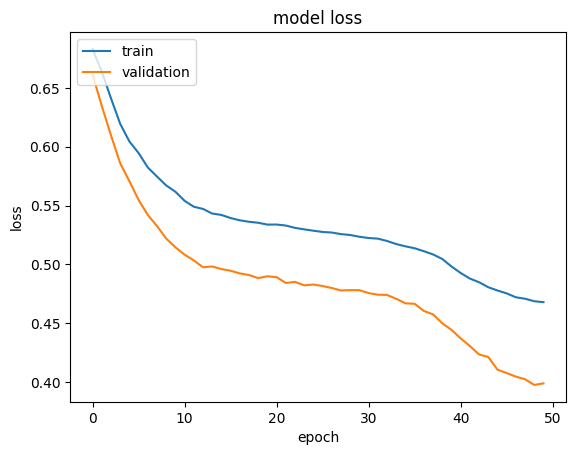

In [55]:
# summarize history for loss and accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

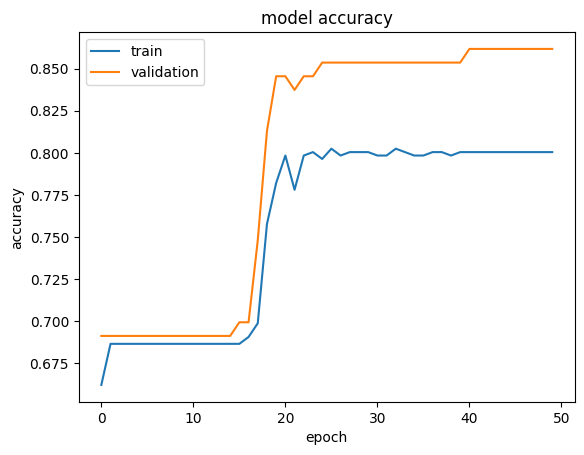

In [56]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()